- 수정 필요 1\
전환율 설명 마크다운에 핵심 KPI / 보조 지표 구분 문장 추가

- 수정 필요 2\
최성영 파트 제목에서 "구매 비교"는 "거래 비교"로 변경 (보조 지표로 사용)

- 수정 필요3\
통계 검정 해석에서 "효과 → "연관성"으로 변경

- 수정 필요 3\
인사이트 출력이나 주석에 "최적" 같은 표현이 있으면 "유망 구간"으로 교체

최성영: 전환 고객 기준 거래 횟수/금액 비교\
김지륜: 채널 분석 전반\
이승복: 오퍼 속성 / 검정\
이주성: 세그먼트 / 프로모션 유형 / 세부 오퍼

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 공통 점검 함수

In [4]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [5]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    df_copied = df.copy()
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}")
    
    if col_name not in df_copied.columns:
        print(f"'{col_name}' 컬럼이 존재하지 않습니다.")
        return
    
    summary_df = df_copied[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df_copied) * 100).round(2)
    
    print("전체 행 수:", len(df_copied))
    print(f"{col_name} 고유값 개수(결측 포함):", df_copied[col_name].nunique(dropna=False))
    print()
    
    display(summary_df.head(10))

# 데이터 로드

In [6]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("data/funnel_final.csv")

# 테이블 복제
funnel = df.copy()
check_basic_info(funnel, 'funnel_final')


funnel_final의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,39
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
days_as_member,float64,66501,87.18,9776,12.82,1707
member_year,float64,66501,87.18,9776,12.82,6
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22


[테이블 요약]


,customer_id,offer_id,time_received,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final,status,channel_count,channel_combo,has_profile,gender_group,age_group,income_group,member_year,member_cohort,days_as_member,days_as_member_group,offer_count,offer_count_group
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,2.0,10.0,7.0,1,1,1,0,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1,converted,3,web + email + mobile,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5,4~6
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,0.0,0.0,4.0,1,1,1,0,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0,viewed_not_converted,3,web + email + mobile,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5,4~6
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,0.0,0.0,3.0,0,1,1,1,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0,viewed_not_converted,3,email + mobile + social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5,4~6
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,5.0,5.0,5.0,1,1,1,1,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1,converted,4,web + email + mobile + social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5,4~6
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,2.0,10.0,10.0,1,1,1,1,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1,converted,4,web + email + mobile + social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5,4~6


# 공통 전처리 / 분석용 파생 컬럼

In [7]:
# ============================================================
# 공통 전처리
# completed 해석이 어려운 informational 제외용 데이터 분리
# 채널 분석에 필요한 channel_count / channel_combo 생성
# 조원 코드에서 공통으로 쓰는 converted_final 컬럼 정리
# ============================================================

# 채널 컬럼 정리
channel_cols = ['web', 'email', 'mobile', 'social']
funnel[channel_cols] = funnel[channel_cols].fillna(0).astype(int)

# 채널 수
funnel['channel_count'] = funnel[channel_cols].sum(axis=1)

# completed 분석용: informational 제외
funnel_offer = funnel[funnel['offer_type'] != 'informational'].copy()

print("공통 파생 컬럼 생성 완료")
display(
    funnel[
        ['web', 'email', 'mobile', 'social', 'channel_count', 'channel_combo', 'converted_final']
    ]
    .drop_duplicates()
    .sort_values(['channel_count', 'channel_combo'])
    .head(3)
)

공통 파생 컬럼 생성 완료


,web,email,mobile,social,channel_count,channel_combo,converted_final
7,1,1,0,0,2,web + email,1
26,1,1,0,0,2,web + email,0
2,0,1,1,1,3,email + mobile + social,0


# 최성영

1. 전환 오퍼 전/후 거래 횟수 · 거래 금액 비교  
   - 기준: `segment == converted` 고객  
   - 목적: 전환 고객의 오퍼 전/후 거래 활동 변화를 보조 지표로 확인

In [8]:
# customer_compare_final 로드
# 고객 단위 전/후 거래 비교 테이블
customer_compare = pd.read_csv("data/customer_compare_final.csv")

print("=" * 80)
print("customer_compare_final 로드")
print("=" * 80)
print("shape:", customer_compare.shape)
display(customer_compare.head())

print("\n[segment 분포]")
display(
    customer_compare['segment']
    .value_counts(dropna=False)
    .rename_axis('segment')
    .reset_index(name='customer_cnt')
)

customer_compare_final 로드
shape: (16994, 6)


,customer_id,segment,before_count,before_amount,after_count,after_amount
0,0009655768c64bdeb2e877511632db8f,converted,4,44.81,12,166.01
1,00116118485d4dfda04fdbaba9a87b5c,not_converted,0,0.00,0,0.00
2,0011e0d4e6b944f998e987f904e8c1e5,converted,2,25.42,5,88.02
3,0020c2b971eb4e9188eac86d93036a77,converted,0,0.00,6,149.43
4,0020ccbbb6d84e358d3414a3ff76cffd,converted,10,136.26,11,137.78



[segment 분포]


,segment,customer_cnt
0,converted,12774
1,not_converted,4220


In [9]:
# 전환 고객 기준 오퍼 전/후 거래 비교표
# not_converted는 비교 기준 시점이 없어 전/후 값이 0으로 채워질 수 있기 떄문에
# 메인 비교는 converted 고객만 사용

converted_compare = customer_compare[
    customer_compare['segment'] == 'converted'
].copy()

offer_effect_summary = pd.DataFrame({
    '지표': ['거래 횟수', '거래 금액'],
    '오퍼 전 평균': [
        converted_compare['before_count'].mean(),
        converted_compare['before_amount'].mean()
    ],
    '오퍼 후 평균': [
        converted_compare['after_count'].mean(),
        converted_compare['after_amount'].mean()
    ],
    '오퍼 전 중앙값': [
        converted_compare['before_count'].median(),
        converted_compare['before_amount'].median()
    ],
    '오퍼 후 중앙값': [
        converted_compare['after_count'].median(),
        converted_compare['after_amount'].median()
    ]
})

offer_effect_summary['평균 증감'] = (
    offer_effect_summary['오퍼 후 평균'] - offer_effect_summary['오퍼 전 평균']
)

offer_effect_summary['평균 증감률(%)'] = np.where(
    offer_effect_summary['오퍼 전 평균'] != 0,
    offer_effect_summary['평균 증감'] / offer_effect_summary['오퍼 전 평균'] * 100,
    np.nan
)

offer_effect_summary = offer_effect_summary.round(2)

offer_effect_detail = (
    converted_compare[['before_count', 'after_count', 'before_amount', 'after_amount']]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': '컬럼'})
    .round(2)
)

print("=" * 80)
print("최성영 분석: 전환 고객 기준 오퍼 전/후 거래 비교")
print("=" * 80)
print("분석 대상 고객 수:", converted_compare['customer_id'].nunique())
display(offer_effect_summary)

print("\n[세부 요약]")
display(offer_effect_detail)

최성영 분석: 전환 고객 기준 오퍼 전/후 거래 비교
분석 대상 고객 수: 12774


,지표,오퍼 전 평균,오퍼 후 평균,오퍼 전 중앙값,오퍼 후 중앙값,평균 증감,평균 증감률(%)
0,거래 횟수,4.64,7.91,3.00,6.00,3.27,70.39
1,거래 금액,75.18,130.89,38.09,86.35,55.71,74.10



[세부 요약]


,컬럼,mean,median,std,min,max
0,before_count,4.64,3.00,4.62,0.0,36.00
1,after_count,7.91,6.00,5.83,0.0,43.00
2,before_amount,75.18,38.09,118.06,0.0,2142.57
3,after_amount,130.89,86.35,166.33,0.0,2534.69


# 조준익
조준익 파트는 별도 코드가 추가될 예정

# 김지륜

채널 관련 분석
- 기준 데이터는 `informational`을 제외한 `funnel_offer`

In [10]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

print("received 기준 전체 건수:", len(funnel_offer))
print("completed가 붙은 건수:", funnel_offer['has_completed_rc'].sum())
print("최종 전환 건수:", funnel_offer['converted_final'].sum())
print()
print("최종 전환율:", round(funnel_offer['converted_final'].mean() * 100, 2), "%")

기본 검증단계
received 기준 전체 건수: 61042
completed가 붙은 건수: 33152
최종 전환 건수: 33152

최종 전환율: 54.31 %


In [11]:
# 채널 분석용 기준 테이블 생성
# 공통 전처리에서 만든 channel_count / channel_combo / converted_final 사용

channel_base = funnel_offer.copy()

In [12]:
# ============================================================
#  공통 전환율 집계 함수
# ============================================================
def conversion_table(df, group_col):
    result = (
        df.groupby(group_col)
          .agg(
              received_count=('customer_id', 'size'),
              converted_count=('converted_final', 'sum'),
              conversion_rate=('converted_final', 'mean')
          )
          .reset_index()
    )

    result['conversion_rate'] = (result['conversion_rate'] * 100).round(2)
    return result.sort_values('conversion_rate', ascending=False).reset_index(drop=True)

In [13]:
# 공통 막대그래프 함수
def plot_conversion_rate(df, group_col, title):
    plot_df = conversion_table(df, group_col)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(plot_df[group_col].astype(str), plot_df['conversion_rate'])

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom'
        )
    
    plt.title(title)
    plt.xlabel(str(group_col))
    plt.ylabel('Conversion Rate (%)')
    plt.ylim(0, plot_df['conversion_rate'].max() * 1.15 if len(plot_df) > 0 else 1)
    plt.tight_layout()
    plt.show()

web 채널 여부별 최종 전환율


,web,received_count,converted_count,conversion_rate
0,1,53384,29517,55.29
1,0,7658,3635,47.47


email 채널 여부별 최종 전환율


,email,received_count,converted_count,conversion_rate
0,1,61042,33152,54.31


mobile 채널 여부별 최종 전환율


,mobile,received_count,converted_count,conversion_rate
0,1,53374,29818,55.87
1,0,7668,3334,43.48


social 채널 여부별 최종 전환율


,social,received_count,converted_count,conversion_rate
0,1,38065,21557,56.63
1,0,22977,11595,50.46


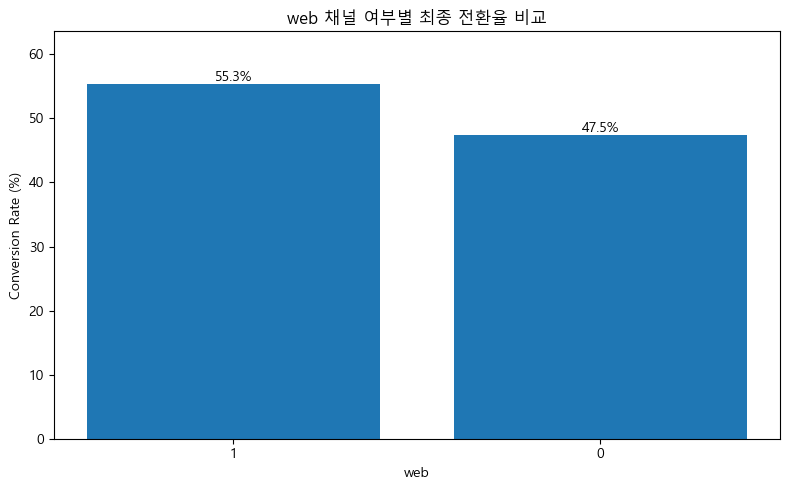

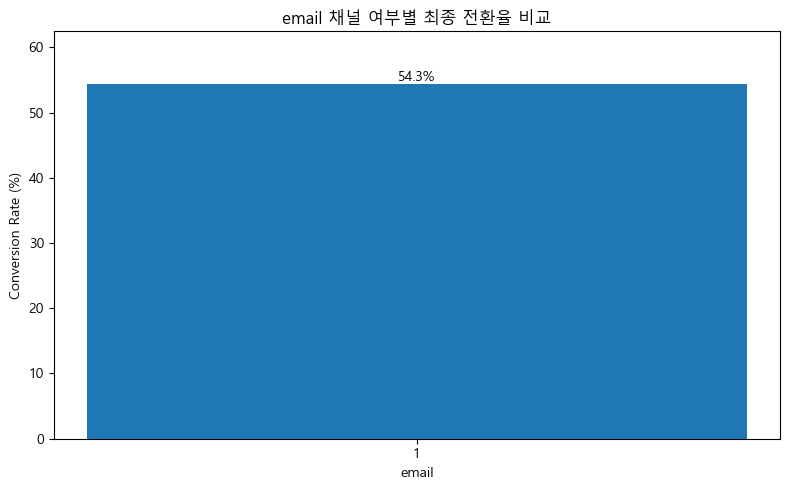

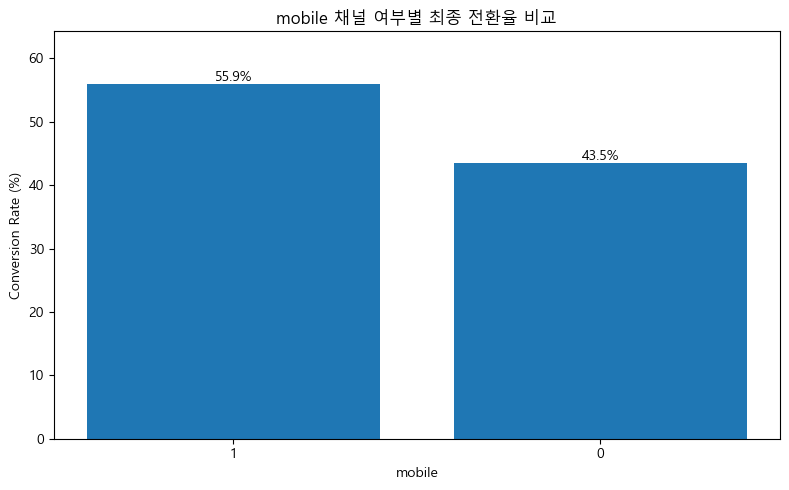

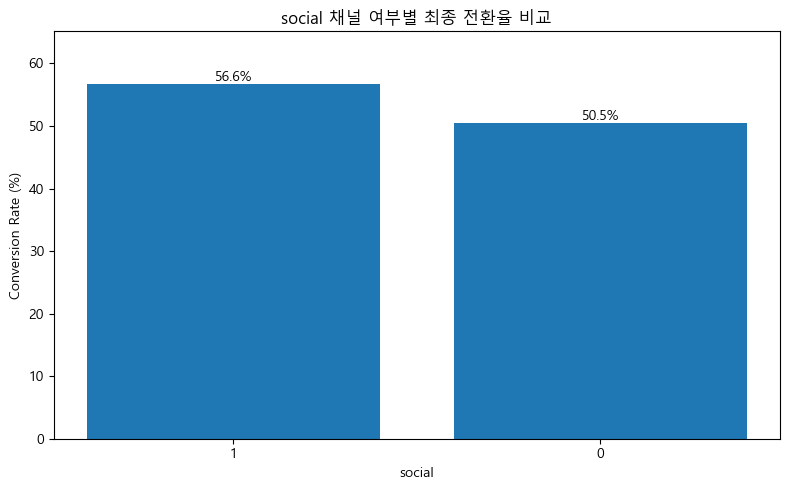

In [14]:
# 개별 채널 여부별 최종 전환율
for ch in channel_cols:
    print("=" * 80)
    print(f"{ch} 채널 여부별 최종 전환율")
    print("=" * 80)
    display(conversion_table(channel_base, ch))

for ch in channel_cols:
    plot_conversion_rate(channel_base, ch, f'{ch} 채널 여부별 최종 전환율 비교')

채널 조합별 최종 전환율


,channel_combo,received_count,converted_count,conversion_rate
0,web + email + mobile + social,30407,17922,58.94
1,web + email + mobile,15309,8261,53.96
2,email + mobile + social,7658,3635,47.47
3,web + email,7668,3334,43.48


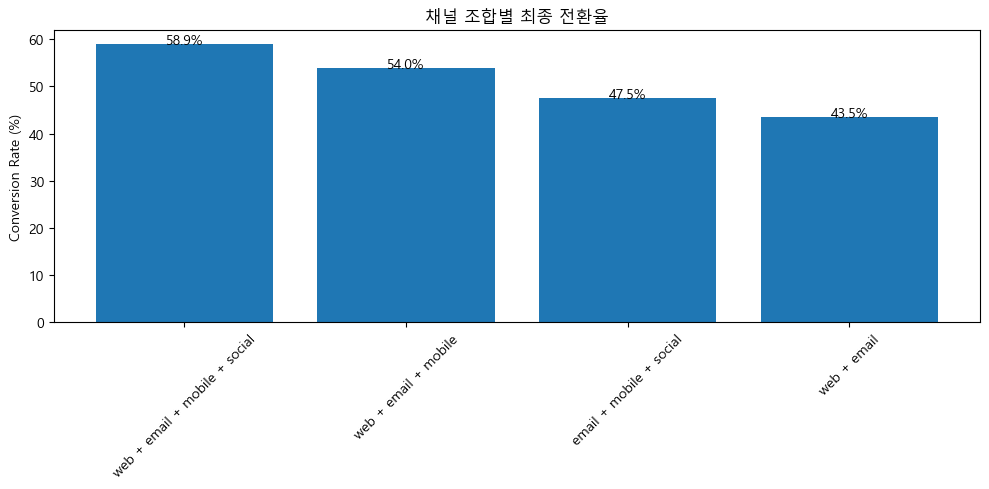

In [15]:
# 채널 조합별 최종 전환율

channel_combo_result = conversion_table(channel_base, 'channel_combo')

print("=" * 80)
print("채널 조합별 최종 전환율")
print("=" * 80)
display(channel_combo_result)

top_channel = channel_combo_result.head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(top_channel['channel_combo'], top_channel['conversion_rate'])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}%', ha='center')

plt.xticks(rotation=45)
plt.title('채널 조합별 최종 전환율')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

mobile 포함 여부별 최종 전환율


,mobile_flag,received_count,converted_count,conversion_rate
0,1,53374,29818,55.87
1,0,7668,3334,43.48


채널 수별 최종 전환율


,channel_count,received_count,converted_count,conversion_rate
0,4,30407,17922,58.94
1,3,22967,11896,51.80
2,2,7668,3334,43.48


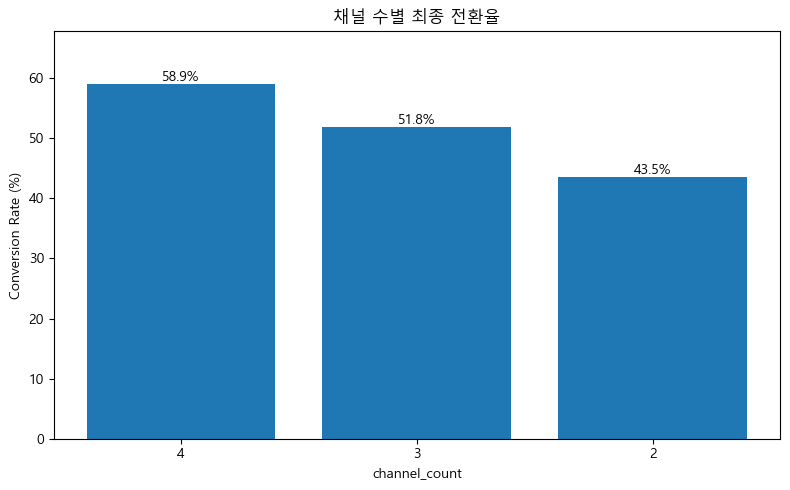

In [16]:
# mobile 포함 여부 / 채널 수별 최종 전환율

channel_base['mobile_flag'] = channel_base['mobile']

print("=" * 80)
print("mobile 포함 여부별 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, 'mobile_flag'))

print("=" * 80)
print("채널 수별 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, 'channel_count'))

plot_conversion_rate(channel_base, 'channel_count', '채널 수별 최종 전환율')

In [17]:
# offer_type × mobile / 채널별 보조 표
# 메인 그래프 외에 세부 분해 확인용 표

print("=" * 80)
print("offer_type × mobile 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, ['offer_type', 'mobile']))

print("=" * 80)
print("채널별 보조 비교표")
print("=" * 80)
display(conversion_table(channel_base, 'mobile'))
display(conversion_table(channel_base, 'web'))
display(conversion_table(channel_base, 'email'))
display(conversion_table(channel_base, 'social'))

offer_type × mobile 최종 전환율


,offer_type,mobile,received_count,converted_count,conversion_rate
0,discount,1,22875,14317,62.59
1,bogo,1,30499,15501,50.82
2,discount,0,7668,3334,43.48


채널별 보조 비교표


,mobile,received_count,converted_count,conversion_rate
0,1,53374,29818,55.87
1,0,7668,3334,43.48


,web,received_count,converted_count,conversion_rate
0,1,53384,29517,55.29
1,0,7658,3635,47.47


,email,received_count,converted_count,conversion_rate
0,1,61042,33152,54.31


,social,received_count,converted_count,conversion_rate
0,1,38065,21557,56.63
1,0,22977,11595,50.46


# 이승복

status,converted,not_viewed,viewed_not_converted
offer_type,,,
bogo,0.508246,0.096069,0.395685
discount,0.577907,0.188194,0.233900


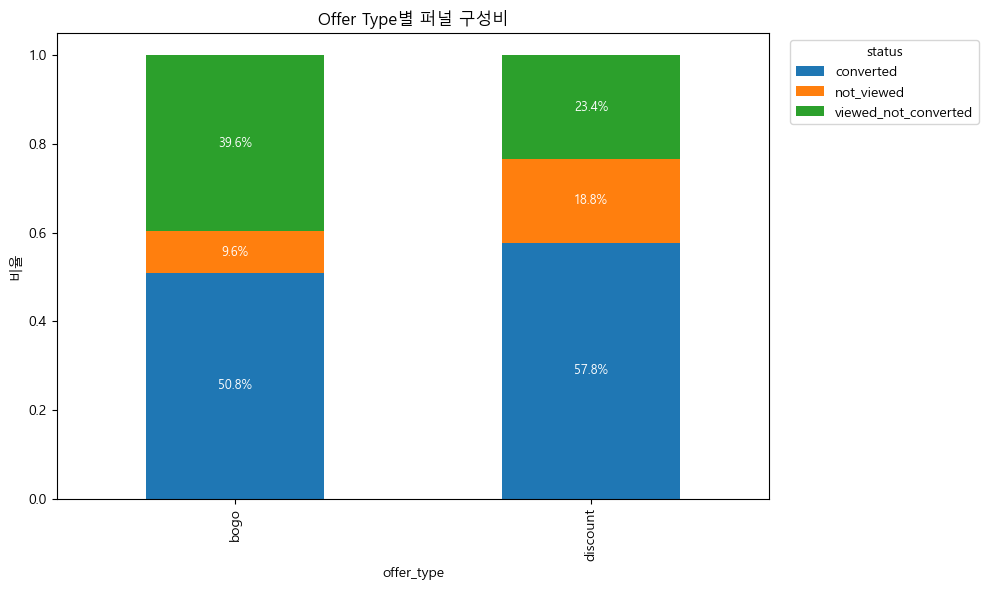

In [18]:
# Offer Type별 퍼널 구성비

def make_status_summary(df, group_col):
    temp = df.copy()

    temp['status'] = np.select(
        [
            temp['converted_rc'] == 1,
            temp['has_viewed'] == 0,
            (temp['has_viewed'] == 1) & (temp['converted_rc'] == 0)
        ],
        [
            'converted',
            'not_viewed',
            'viewed_not_converted'
        ],
        default='other'
    )

    summary = (
        temp.groupby([group_col, 'status'])
        .size()
        .unstack(fill_value=0)
    )

    ratio = summary.div(summary.sum(axis=1), axis=0)
    return ratio

def plot_status_stacked_bar(ratio, group_col, title):
    ax = ratio[['converted', 'not_viewed', 'viewed_not_converted']].plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('비율')
    ax.legend(title='status', bbox_to_anchor=(1.02, 1), loc='upper left')

    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append(f'{h:.1%}' if h > 0.03 else '')
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white')

    plt.tight_layout()
    plt.show()

offer_type_ratio = make_status_summary(funnel_offer, 'offer_type')
display(offer_type_ratio)

plot_status_stacked_bar(
    offer_type_ratio,
    group_col='offer_type',
    title='Offer Type별 퍼널 구성비'
)

,offer_reward,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,2.0,15229,11388,9209,6763,0.747784,0.593871,0.604702
1,3.0,7646,7330,5108,4377,0.958671,0.597135,0.668062
2,5.0,22916,13988,11899,6992,0.610403,0.499857,0.519244
3,10.0,15251,13914,6936,5364,0.912334,0.385511,0.454790


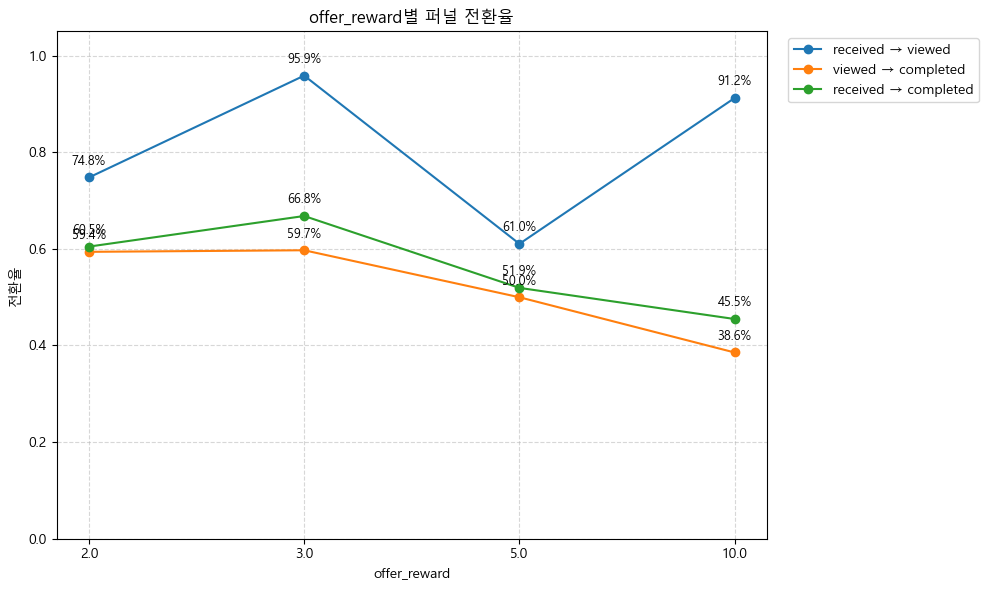

,difficulty,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,5.0,15248,11336,8565,5660,0.743442,0.499294,0.561713
1,7.0,7646,7330,5108,4377,0.958671,0.597135,0.668062
2,10.0,30480,25302,16145,12127,0.830118,0.479290,0.529692
3,20.0,7668,2652,3334,1332,0.345853,0.502262,0.434794


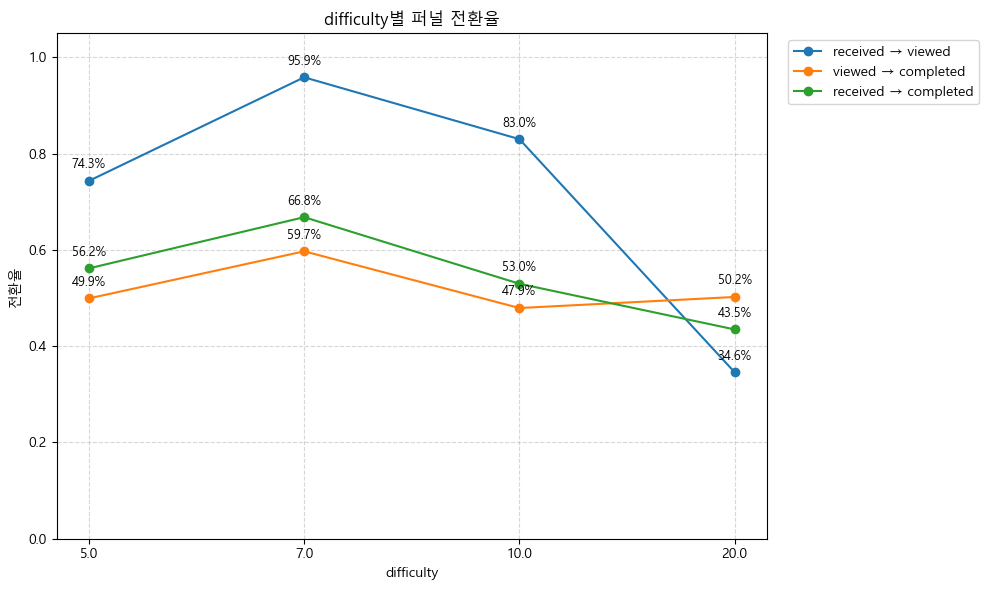

,duration,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,5.0,15164,14443,7563,6287,0.952453,0.435297,0.498747
1,7.0,30613,22198,17004,11242,0.725117,0.506442,0.555450
2,10.0,15265,9979,8585,5967,0.653718,0.597956,0.562398


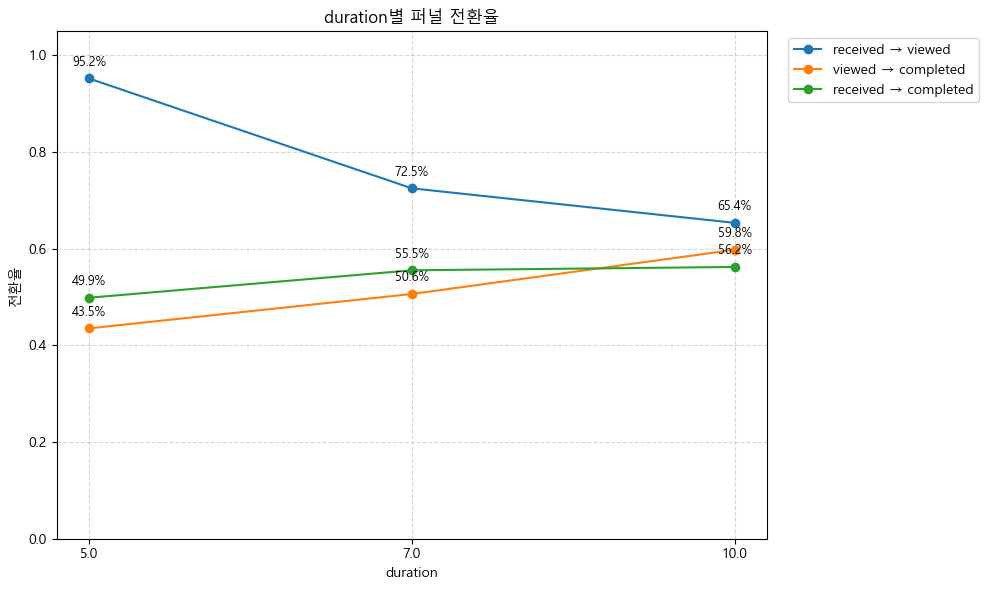

In [19]:
# reward / difficulty / duration별 퍼널 전환율

def make_funnel_summary(df, group_col):
    summary = df.groupby(group_col).agg(
        received=('customer_id', 'count'),
        viewed=('has_viewed', 'sum'),
        completed=('has_completed_rc', 'sum'),
        completed_after_view=('has_completed_after_view', 'sum')
    ).reset_index()

    summary['rv_rate'] = summary['viewed'] / summary['received']
    summary['vc_rate'] = np.where(
        summary['viewed'] > 0,
        summary['completed_after_view'] / summary['viewed'],
        np.nan
    )
    summary['rc_rate'] = summary['completed'] / summary['received']

    return summary.sort_values(group_col)

def plot_funnel_conversion(summary, group_col, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(summary))

    ax.plot(x, summary['rv_rate'], marker='o', label='received → viewed')
    ax.plot(x, summary['vc_rate'], marker='o', label='viewed → completed')
    ax.plot(x, summary['rc_rate'], marker='o', label='received → completed')

    for col in ['rv_rate', 'vc_rate', 'rc_rate']:
        for i, y in enumerate(summary[col]):
            if pd.notna(y):
                ax.text(i, y + 0.02, f'{y:.1%}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(summary[group_col])
    ax.set_ylim(0, 1.05)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('전환율')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

for col in ['offer_reward', 'difficulty', 'duration']:
    summary = make_funnel_summary(funnel_offer, col)
    display(summary)
    plot_funnel_conversion(
        summary,
        group_col=col,
        title=f'{col}별 퍼널 전환율'
    )

In [20]:
# 오퍼 속성과 전환 간 상관계수
corr_df = funnel_offer[
    ['offer_reward', 'difficulty', 'duration', 'converted_rc']
].copy()

corr = corr_df.corr()

print("="*60)
print("상관계수 (Correlation)")
print("="*60)
display(corr)

상관계수 (Correlation)


,offer_reward,difficulty,duration,converted_rc
offer_reward,1.000000,0.063459,-0.455509,-0.126113
difficulty,0.063459,1.000000,0.643020,-0.093056
duration,-0.455509,0.643020,1.000000,0.041103
converted_rc,-0.126113,-0.093056,0.041103,1.000000


In [21]:
# 전환 여부에 따른 차이 검정 (Welch t-test)
from scipy.stats import ttest_ind

print("="*60)
print("p-value (전환 여부에 따른 차이 검정)")
print("="*60)

for col in ['offer_reward', 'difficulty', 'duration']:
    group1 = funnel_offer[funnel_offer['converted_rc'] == 1][col]
    group0 = funnel_offer[funnel_offer['converted_rc'] == 0][col]

    stat, p = ttest_ind(group1, group0, equal_var=False)

    print(f"\n[{col}]")
    print(f"t-statistic: {stat:.4f}")
    print(f"p-value: {p:.6f}")

p-value (전환 여부에 따른 차이 검정)

[offer_reward]
t-statistic: -31.2580
p-value: 0.000000

[difficulty]
t-statistic: -22.8414
p-value: 0.000000

[duration]
t-statistic: 10.1534
p-value: 0.000000


In [22]:
# Offer Type vs Conversion 카이제곱 검정 + 연관성 크기 참고

from scipy.stats import chi2_contingency

ct = pd.crosstab(funnel_offer['offer_type'], funnel_offer['converted_rc'])

chi2, p, dof, expected = chi2_contingency(ct)

# 연관성 크기 참고: Cramér's V
n = ct.to_numpy().sum()
r, c = ct.shape
cramers_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

if cramers_v < 0.1:
    interpretation = "매우 작은 연관성"
elif cramers_v < 0.3:
    interpretation = "작은 연관성"
elif cramers_v < 0.5:
    interpretation = "중간 연관성"
else:
    interpretation = "큰 연관성"

print("=" * 60)
print("Offer Type vs Conversion (카이제곱 검정)")
print("=" * 60)
print(f"chi2 statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")
print(f"연관성 해석: {interpretation}")
print()

print("[교차표]")
display(ct)

expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("[기대빈도표]")
display(expected_df)


Offer Type vs Conversion (카이제곱 검정)
chi2 statistic: 298.1473
p-value: 0.000000
degrees of freedom: 1
Cramér's V: 0.0699
연관성 해석: 매우 작은 연관성

[교차표]


converted_rc,0,1
offer_type,,
bogo,14998,15501
discount,12892,17651


[기대빈도표]


converted_rc,0,1
offer_type,,
bogo,13934.948232,16564.051768
discount,13955.051768,16587.948232


필요하다 판단되는 요소

- reward 수준별 전환율의 p-value
- difficulty 수준별 전환율의 p-value
- duration 수준별 전환율의 p-value

# 이주성

1. 어떤 고객 세그먼트가 오퍼를 더 잘 열람하는가  
2. 오퍼를 본 뒤 completed까지 더 잘 이어지는 고객군은 누구인가  
3. 프로모션 유형별로 열람 유도와 완료 유도 성격이 어떻게 다른가  
4. 채널 조합과 세부 오퍼 수준에서 성과 차이가 존재하는가

In [23]:
# 분석 기준 데이터 정리
# - 열람 분석은 informational 포함
# - viewed → completed 분석은 completed 해석이 가능한 bogo / discount만 사용


segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['~30대', '40대', '50대', '60대', '70대+', 'Missing'],
    'income_group': ['~4만', '4~6만', '6~8만', '8~10만', '10만+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}

offer_order = ['bogo', 'discount', 'informational']

funnel_all = funnel.copy() # 열람 분석용: informational 포함

# viewed 이후 completed 분석용: informational 제외
funnel_viewed = funnel_all[funnel_all['converted_rv'] == 1].copy()
funnel_vc_main = funnel_viewed[funnel_viewed['offer_type'].isin(['bogo', 'discount'])].copy()

print('열람 분석용 데이터:', funnel_all.shape)
print('viewed → completed 분석용 데이터:', funnel_vc_main.shape)

열람 분석용 데이터: (76277, 39)
viewed → completed 분석용 데이터: (46620, 39)


---

In [24]:
# 프로모션 유형별 요약표
# - 열람률은 informational 포함
# - viewed → completed 전환률은 bogo / discount만 사용

offer_type_summary = (
    funnel_all
    .groupby('offer_type', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_type_summary['rv_rate'] = offer_type_summary['viewed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rc_rate'] = offer_type_summary['completed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rvc_rate'] = offer_type_summary['strict_completed_cnt'] / offer_type_summary['received_cnt'] * 100

offer_type_summary['offer_type'] = pd.Categorical(
    offer_type_summary['offer_type'],
    categories=offer_order,
    ordered=True
)
offer_type_summary = offer_type_summary.sort_values('offer_type').reset_index(drop=True)

offer_type_vc_summary = (
    funnel_vc_main
    .groupby('offer_type', dropna=False)
    .agg(
        viewed_cnt=('customer_id', 'size'),
        completed_after_view_cnt=('converted_vc', 'sum'),
        avg_vc_time=('vc_time_diff', 'mean')
    )
    .reset_index()
)

offer_type_vc_summary['vc_rate'] = (
    offer_type_vc_summary['completed_after_view_cnt'] /
    offer_type_vc_summary['viewed_cnt'] * 100
)

offer_type_vc_summary['offer_type'] = pd.Categorical(
    offer_type_vc_summary['offer_type'],
    categories=['bogo', 'discount'],
    ordered=True
)
offer_type_vc_summary = offer_type_vc_summary.sort_values('offer_type').reset_index(drop=True)

display(offer_type_summary)
display(offer_type_vc_summary)

,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


---

## 세그먼트별 열람 반응

In [25]:
# 세그먼트별 열람률 요약 함수
def make_segment_rv_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100
    summary['segment_share'] = summary['received_cnt'] / summary['received_cnt'].sum() * 100

    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        summary = summary.sort_values(segment_col).reset_index(drop=True)

    return summary


def make_segment_offer_rv_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100

    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )

    summary['offer_type'] = pd.Categorical(
        summary['offer_type'],
        categories=offer_order,
        ordered=True
    )

    summary = summary.sort_values([segment_col, 'offer_type']).reset_index(drop=True)
    return summary

In [26]:
# 세그먼트 × offer_type 열람률 그래프
def plot_segment_offer_point(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    df_a[segment_col] = df_a[segment_col].astype(str)

    actual_levels = df_a[segment_col].dropna().unique().tolist()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in actual_levels]
    else:
        order_list = actual_levels

    df_a = df_a[df_a[segment_col].isin(order_list)].copy()

    df_a[segment_col] = pd.Categorical(
        df_a[segment_col],
        categories=order_list,
        ordered=True
    )

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'].astype(str),
        categories=offer_order,
        ordered=True
    )

    df_a = df_a.sort_values([segment_col, 'offer_type'])

    plt.figure(figsize=(9, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y='rv_rate',
        hue=segment_col,
        order=offer_order,
        dodge=0.25,
        markers='o',
        linestyles='-'
    )

    plt.title(f'[{group_title}] 세그먼트별 프로모션 유형 열람률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title=segment_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [27]:
# 열람 단계 핵심 요약표
# - 본문에서는 연령대 / 소득대 중심으로 해석
# - 성별 / 가입코호트는 보조 확인용

gender_rv_summary = make_segment_rv_summary(funnel_all, 'gender_group')
age_rv_summary = make_segment_rv_summary(funnel_all, 'age_group')
income_rv_summary = make_segment_rv_summary(funnel_all, 'income_group')
cohort_rv_summary = make_segment_rv_summary(funnel_all, 'member_cohort')

age_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'age_group')
income_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'income_group')

print('=' * 70)
print('열람 단계 핵심 요약표')
print('=' * 70)
print('[연령대별 열람률]')
display(age_rv_summary)
print('[소득대별 열람률]')
display(income_rv_summary)
print('[성별별 열람률 - 보조]')
display(gender_rv_summary)
print('[가입코호트별 열람률 - 보조]')
display(cohort_rv_summary)


열람 단계 핵심 요약표
[연령대별 열람률]


,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~30대,7688,5227,67.989074,10.079054
1,40대,7202,5203,72.243821,9.441903
2,50대,10626,8206,77.225673,13.930805
3,60대,16177,11943,73.827038,21.208228
4,70대+,24808,18264,73.621412,32.523565
5,Missing,9776,7724,79.009820,12.816445


[소득대별 열람률]


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~4만,9667,6514,67.383883,12.673545
1,4~6만,20458,14986,73.252517,26.820667
2,6~8만,20415,15525,76.047024,26.764293
3,8~10만,11435,8945,78.224749,14.991413
4,10만+,4526,2873,63.477684,5.933637
5,Missing,9776,7724,79.009820,12.816445


[성별별 열람률 - 보조]


,gender_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,F,27456,20295,73.918269,35.995123
1,M,38129,27779,72.855307,49.987545
2,O,916,769,83.951965,1.200886
3,Missing,9776,7724,79.009820,12.816445


[가입코호트별 열람률 - 보조]


,member_cohort,received_cnt,viewed_cnt,rv_rate,segment_share
0,2013-2014,4199,3097,73.755656,5.504936
1,2015-2016,20670,15366,74.339623,27.098601
2,2017-2018,41632,30380,72.972713,54.580018
3,Missing,9776,7724,79.009820,12.816445


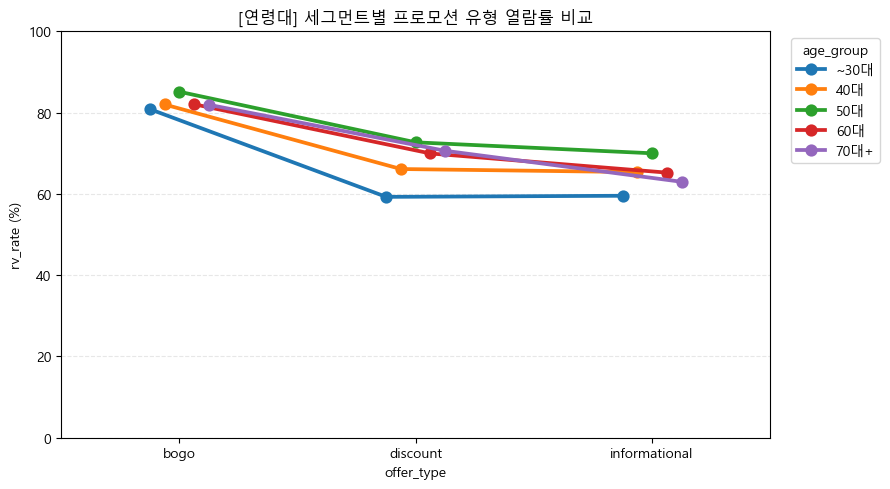

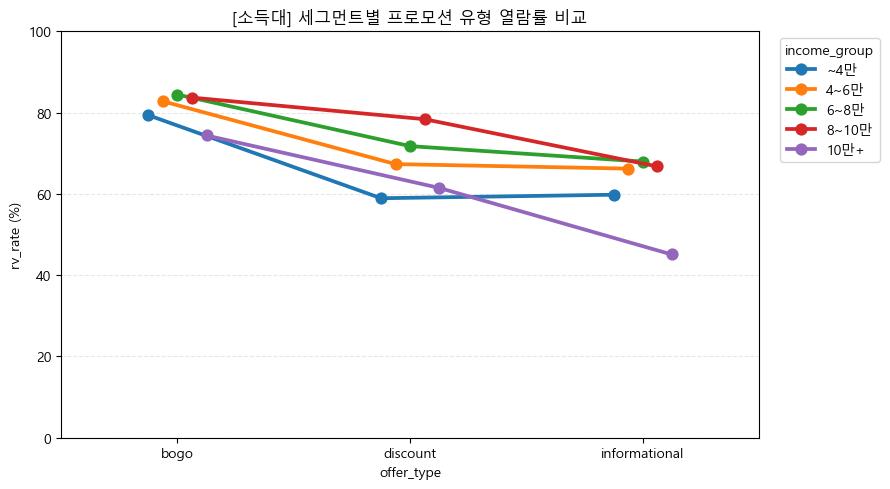

In [28]:
plot_segment_offer_point(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_offer_point(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])

---

## viewed → completed 전환 분석

In [29]:
# viewed → completed 분석 함수
def make_segment_vc_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),
            completed_after_view_cnt=('converted_vc', 'sum'),
            avg_vc_time=('vc_time_diff', 'mean')
        )
        .reset_index()
    )

    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100

    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        summary = summary.sort_values(segment_col).reset_index(drop=True)

    return summary


def plot_segment_vc_bar(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].astype(str).tolist() or x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=df_a, x=segment_col, y='vc_rate')

    plt.title(f'[{group_title}] 고객군별 viewed → completed 전환률')
    plt.xlabel(segment_col)
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['vc_rate']):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [30]:
# viewed → completed 전환율
# completed 해석이 가능한 bogo, discount만 사용

gender_vc_summary = make_segment_vc_summary(funnel_vc_main, 'gender_group')
age_vc_summary = make_segment_vc_summary(funnel_vc_main, 'age_group')
income_vc_summary = make_segment_vc_summary(funnel_vc_main, 'income_group')
cohort_vc_summary = make_segment_vc_summary(funnel_vc_main, 'member_cohort')

print('=' * 70)
print('viewed → completed 핵심 요약표')
print('=' * 70)
display(gender_vc_summary)
display(age_vc_summary)
display(income_vc_summary)
display(cohort_vc_summary)

viewed → completed 핵심 요약표


,gender_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,F,16765,10507,40.514133,62.672234
1,M,22881,11655,47.171686,50.937459
2,O,612,390,41.646154,63.725490
3,Missing,6362,944,81.165254,14.838101


,age_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,~30대,4333,1953,47.794163,45.072698
1,40대,4268,2267,44.911337,53.116214
2,50대,6716,3779,44.921408,56.268612
3,60대,9807,5734,42.304499,58.468441
4,70대+,15134,8819,43.567525,58.272763
5,Missing,6362,944,81.165254,14.838101


,income_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,~4만,5390,2322,51.361757,43.079777
1,4~6만,12227,6231,47.049591,50.960988
2,6~8만,12756,7505,42.722718,58.835058
3,8~10만,7413,4826,41.035226,65.101848
4,10만+,2472,1668,36.338129,67.475728
5,Missing,6362,944,81.165254,14.838101


,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2013-2014,2550,1427,55.286615,55.960784
1,2015-2016,12659,9209,36.243675,72.746662
2,2017-2018,25049,11916,48.594159,47.570761
3,Missing,6362,944,81.165254,14.838101


---

## 프로모션 유형별 비교

In [31]:
# 프로모션 유형별 비교 그래프
def plot_offer_type_rv(summary_df):
    df_a = summary_df.copy()
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount', 'informational'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=df_a, x='offer_type', y='rv_rate')

    plt.title('프로모션 유형별 열람률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['rv_rate']):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_offer_type_vc(summary_df):
    df_a = summary_df.copy()
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    plt.figure(figsize=(7, 4.5))
    sns.barplot(data=df_a, x='offer_type', y='vc_rate')

    plt.title('프로모션 유형별 viewed → completed 전환률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['vc_rate']):
        plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


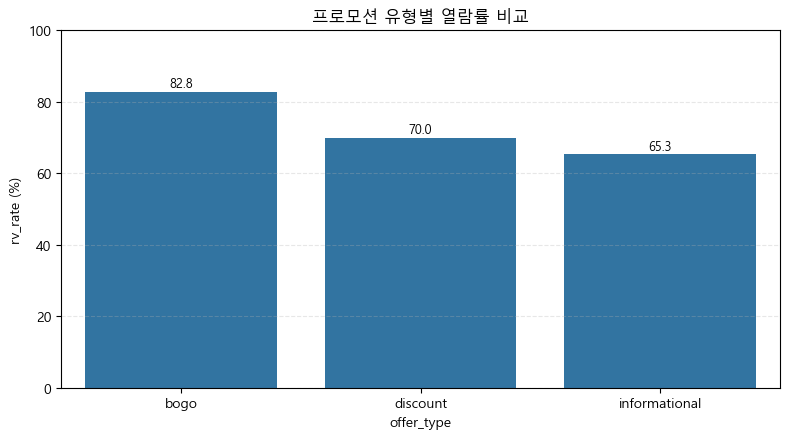

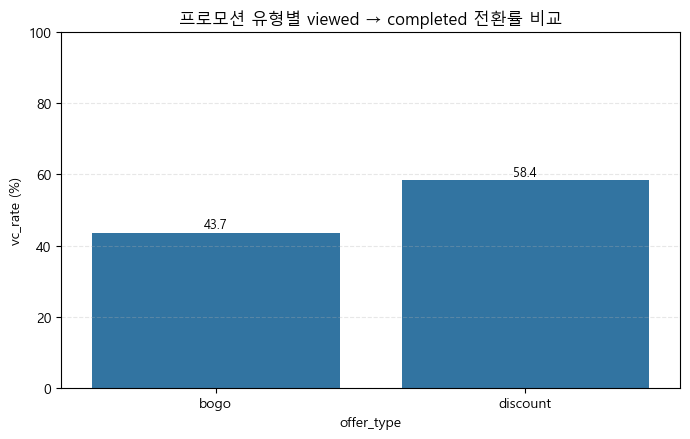

In [32]:
plot_offer_type_rv(offer_type_summary)
plot_offer_type_vc(offer_type_vc_summary)

---

## 채널별 조합 비교

In [33]:
# 채널 조합 데이터 생성
channel_cols = ['web', 'email', 'mobile', 'social']


def make_channel_combo(row):
    channels = []

    if row['web'] == 1:
        channels.append('web')
    if row['email'] == 1:
        channels.append('email')
    if row['mobile'] == 1:
        channels.append('mobile')
    if row['social'] == 1:
        channels.append('social')

    return ' + '.join(channels) if channels else 'none'


funnel_channel = funnel_all.copy()
for col in channel_cols:
    funnel_channel[col] = funnel_channel[col].fillna(0).astype(int)

funnel_channel['channel_combo'] = funnel_channel.apply(make_channel_combo, axis=1)

channel_summary = (
    funnel_channel
    .groupby('channel_combo', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_summary['rv_rate'] = channel_summary['viewed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rc_rate'] = channel_summary['completed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rvc_rate'] = channel_summary['strict_completed_cnt'] / channel_summary['received_cnt'] * 100

channel_offer_summary = (
    funnel_channel
    .groupby(['channel_combo', 'offer_type'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_offer_summary['rv_rate'] = channel_offer_summary['viewed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rc_rate'] = channel_offer_summary['completed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rvc_rate'] = channel_offer_summary['strict_completed_cnt'] / channel_offer_summary['received_cnt'] * 100

channel_order = (
    channel_summary
    .sort_values('rvc_rate', ascending=False)['channel_combo']
    .tolist()
)

display(channel_summary.sort_values('rvc_rate', ascending=False))

,channel_combo,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
3,web + email + mobile + social,30407,29100,17922,15299,95.701648,58.940376,50.314072
2,web + email + mobile,22926,11987,8261,4252,52.285615,36.033325,18.546628
1,web + email,7668,2652,3334,1332,34.585290,43.479395,17.370892
0,email + mobile + social,15276,12828,3635,2613,83.974863,23.795496,17.105263


In [34]:
# 채널 조합 그래프
def plot_channel_metric_compare(summary_df):
    df_a = summary_df.copy()

    metric_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }

    plot_df = df_a.melt(
        id_vars=['channel_combo', 'received_cnt'],
        value_vars=['rv_rate', 'rc_rate', 'rvc_rate'],
        var_name='metric',
        value_name='rate'
    )

    plot_df['metric'] = plot_df['metric'].map(metric_map)
    plot_df['channel_combo'] = pd.Categorical(
        plot_df['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    plot_df = plot_df.sort_values(['channel_combo', 'metric'])

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=plot_df,
        x='channel_combo',
        y='rate',
        hue='metric',
        dodge=0.35,
        markers='o',
        linestyles='-'
    )

    plt.title('채널 조합별 전체 반응률 비교')
    plt.xlabel('channel_combo')
    plt.ylabel('rate (%)')
    plt.xticks(rotation=25)
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()


def plot_channel_offer_completion(summary_df, rate_col='rvc_rate'):
    df_a = summary_df.copy()
    df_a = df_a[df_a['offer_type'].isin(['bogo', 'discount'])].copy()

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    df_a = df_a.sort_values(['offer_type', 'channel_combo'])

    rate_name_map = {
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y=rate_col,
        hue='channel_combo',
        dodge=0.3,
        markers='o',
        linestyles='-'
    )

    plt.title(f'채널 조합 × 프로모션 유형 {rate_name} 비교')
    plt.xlabel('offer_type')
    plt.ylabel(f'{rate_name} (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='channel_combo', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


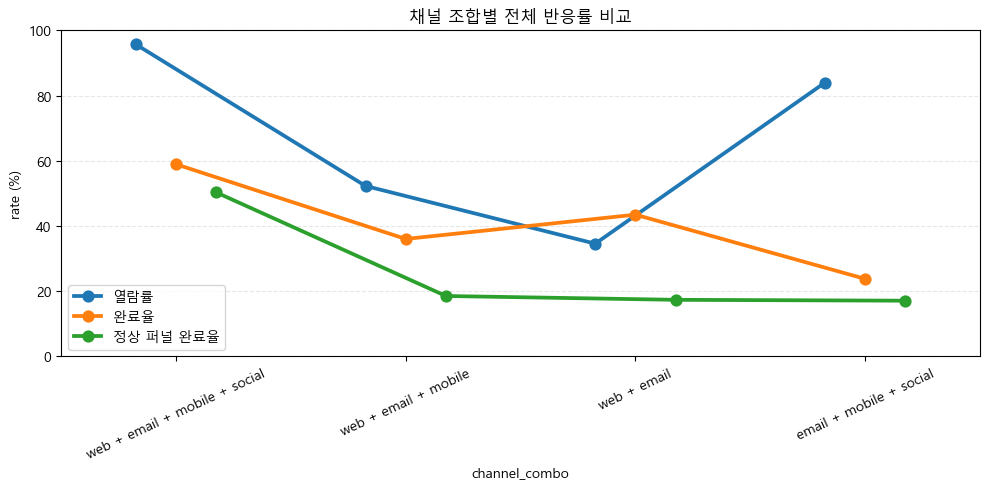

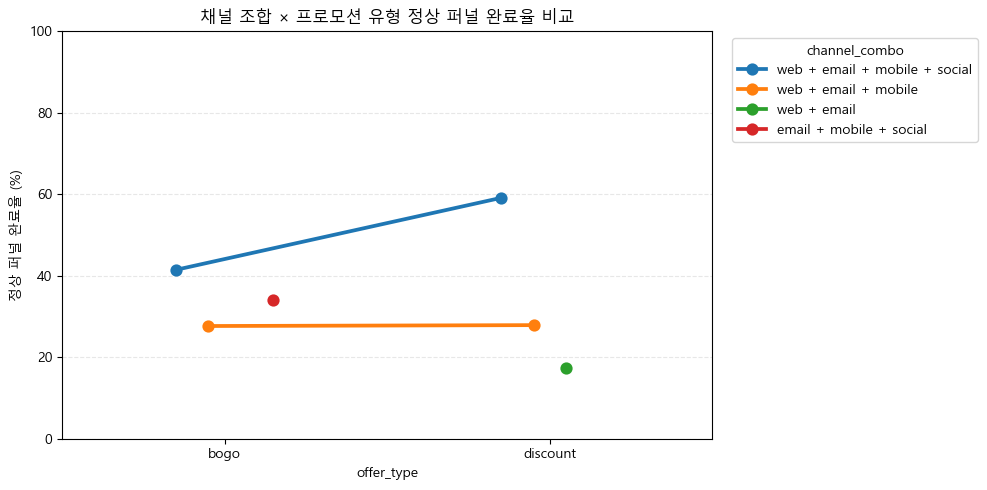

In [35]:
plot_channel_metric_compare(channel_summary)
plot_channel_offer_completion(channel_offer_summary, 'rvc_rate')


---

## 세부 오퍼 비교 (보조 근거)

In [36]:
offer_detail_summary = (
    funnel_all
    .groupby(['offer_type', 'offer_id'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_detail_summary['rv_rate'] = offer_detail_summary['viewed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rc_rate'] = offer_detail_summary['completed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rvc_rate'] = offer_detail_summary['strict_completed_cnt'] / offer_detail_summary['received_cnt'] * 100

top_bogo = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'bogo']
    .sort_values('rvc_rate', ascending=False)
    .head(3)
)

top_discount = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'discount']
    .sort_values('rvc_rate', ascending=False)
    .head(3)
)

top_info = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'informational']
    .sort_values('rv_rate', ascending=False)
    .head(3)
)

print('[bogo 상위 오퍼]')
display(top_bogo[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])

print('[discount 상위 오퍼]')
display(top_discount[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])

print('[informational 상위 오퍼]')
display(top_info[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate']])


[bogo 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
3,f19421c1d4aa40978ebb69ca19b0e20d,7571,95.205389,56.293752,46.704530
0,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,95.285131,43.474253,36.230739
2,ae264e3637204a6fb9bb56bc8210ddfd,7658,87.215983,47.466701,34.121180


[discount 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
7,fafdcd668e3743c1bb461111dcafc2a4,7597,96.445966,69.119389,61.010925
5,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,95.867120,66.806173,57.245619
6,2906b810c7d4411798c6938adc9daaa5,7632,53.210168,51.860587,27.882600


[informational 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate
9,5a8bc65990b245e5a138643cd4eb9837,7618,80.716724,0.0
8,3f207df678b143eea3cee63160fa8bed,7617,49.862150,0.0
